<a href="https://colab.research.google.com/github/SagarLekhak/IMG_689_Graduate_Special_Topics/blob/main/hw5_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Sagar Lekhak, PhD Student.
### Rochester Institute of Technology

## Task 1 :  Using Pretrained Resnet18 to extract features and SVM classifier to classify them

In [2]:
import torch
torch.manual_seed(17)

In [3]:
#!wget http://weegee.vision.ucmerced.edu/datasets/UCMerced_LandUse.zip -P "/content/drive/MyDrive/"


In [4]:
#!unzip "/content/drive/MyDrive/UCMerced_LandUse.zip" -d "/content/drive/MyDrive/UCMerced_LandUse"


In [5]:
# Applying transformations

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [6]:
# Load dataset and split

from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, DataLoader

import os

torch.manual_seed(17)  #fixed seed for reproducibility

# Dataset path
dataset_path = "/content/drive/MyDrive/Fourth Semester/ml_imgs689_ml for rs/hw_5/UCMerced_LandUse/Images"

# Load dataset
dataset = ImageFolder(dataset_path, transform=transform)

print(dataset.classes)

# Class index mapping
class_to_idx = dataset.class_to_idx

print(class_to_idx)


['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
{'agricultural': 0, 'airplane': 1, 'baseballdiamond': 2, 'beach': 3, 'buildings': 4, 'chaparral': 5, 'denseresidential': 6, 'forest': 7, 'freeway': 8, 'golfcourse': 9, 'harbor': 10, 'intersection': 11, 'mediumresidential': 12, 'mobilehomepark': 13, 'overpass': 14, 'parkinglot': 15, 'river': 16, 'runway': 17, 'sparseresidential': 18, 'storagetanks': 19, 'tenniscourt': 20}


In [7]:
# Split dataset

train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader (train_set, batch_size =32, shuffle=False, num_workers=2, pin_memory=True) #shuffle = False because
# while extracting features, we don't want misalsignment in sample and their label, use shuffle = Ture - - during training.
val_loader = DataLoader (val_set, batch_size =32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader (test_set, batch_size =32, shuffle=False, num_workers=2, pin_memory=True)


In [8]:
# Feature extraction using a pretrained network.

import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load resnet18 and remove the final layer (FC layer )
resnet18 = models.resnet18(pretrained=True)
feature_extractor = torch.nn.Sequential(*list(resnet18.children())[:-1])
feature_extractor.to(device)
feature_extractor.eval()

# Function for feature extraction

def extract_features(dataloader, save_path):
    features = []
    labels = []

    with torch.no_grad():                                     # no gradient calculation while extracting features to save memory
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            output = feature_extractor(inputs)                # feature shape = [B, 512, 1, 1]
            output = output.view(output.size(0), -1).cpu()    # convert the feature shape to [B, 512] and save to cpu(as asked)
            features.append(output)
            labels.append(targets)                            # store features and lables from current batch

    features = torch.cat(features)  # merge all batched features and labels into two full tensors of shape
    labels = torch.cat(labels)    # features = [total_images, 512], labels = [total_images]

    torch.save((features, labels), save_path)



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


In [9]:
# Run the above code and save features in cpu (extract features)

extract_features(train_loader, '/content/drive/MyDrive/Fourth Semester/ml_imgs689_ml for rs/hw_5/UCMerced_LandUse/train_features.pt')
extract_features(test_loader, '/content/drive/MyDrive/Fourth Semester/ml_imgs689_ml for rs/hw_5/UCMerced_LandUse/test_features.pt')


In [10]:
# Load extracted features

train_features, train_labels = torch.load('/content/drive/MyDrive/Fourth Semester/ml_imgs689_ml for rs/hw_5/UCMerced_LandUse/train_features.pt')
test_features, test_labels = torch.load('/content/drive/MyDrive/Fourth Semester/ml_imgs689_ml for rs/hw_5/UCMerced_LandUse/test_features.pt')

In [11]:
# Train SVM to classify based on the extracted features.

from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clf = SVC(kernel='linear', C = 1.0)  # C -- regularization strength, higher C - less regularization
clf.fit(train_features, train_labels)

preds = clf.predict(test_features)



Accuracy: 0.9476190476190476
Precision: 0.9373139426710855
Recall: 0.9349513581656439
F1-score: 0.9345005986447985


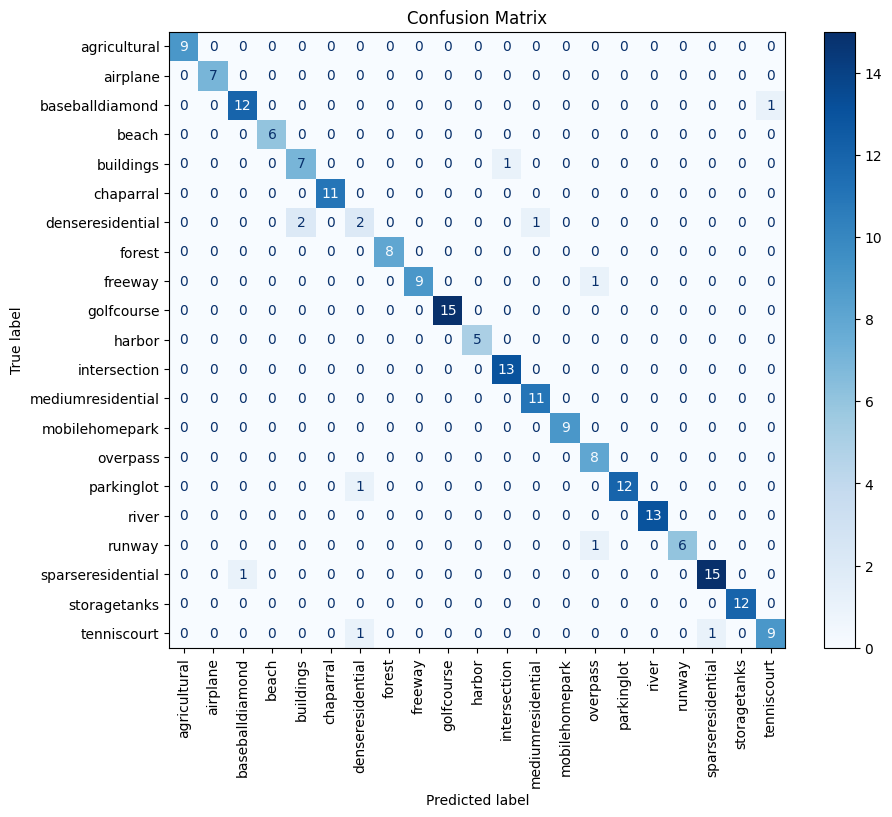

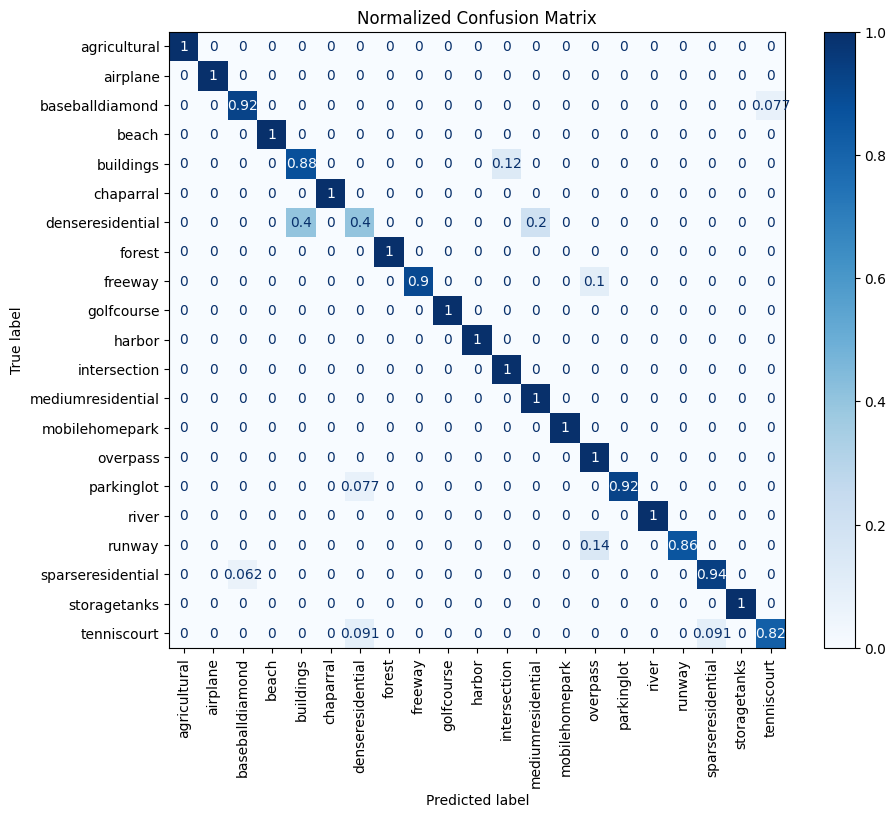

In [12]:
# Evaluate the trained SVM  classifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

print("Accuracy:", accuracy_score(test_labels, preds))
print("Precision:", precision_score(test_labels, preds, average='macro'))
print("Recall:", recall_score(test_labels, preds, average='macro'))
print("F1-score:", f1_score(test_labels, preds, average='macro'))


# Raw confusion matrix
cm = confusion_matrix(test_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_to_idx.keys())
disp.plot(xticks_rotation='vertical', cmap='Blues')

# Resize using the internal figure
disp.figure_.set_size_inches(10, 8)  # Resize the actual plot
plt.title("Confusion Matrix")
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_to_idx.keys())
disp_norm.plot(xticks_rotation='vertical', cmap='Blues')
disp_norm.figure_.set_size_inches(10, 8)  # Resize normalized CM
plt.title("Normalized Confusion Matrix")
plt.show()



## Comments on Task 1 :

In this task, we used the concept of transfer learning, where a large neural network architecture is first trained on a large dataset to learn general visual features, and that knowledge is later transferred to a new, smaller task.

Specifically, we used the **ResNet18** architecture pretrained on the **ImageNet-1k** dataset, which contains over a million images across 1000 object categories. This model has learned to detect low-level to high-level visual patterns such as edges, textures, and object parts.

We applied this pretrained ResNet18 model to the **UCMerced_LandUse** dataset, which consists of 21 land use categories (e.g., runway, forest, freeway, residential). To do this, we removed the final classification layer from ResNet18 (which was specific to ImageNet), and passed our UCMerced images through the remaining layers to extract feature vectors.

**We did not change or update any of the pretrained weights** — we simply used the convolutional layers to transform the images into meaningful feature embeddings. This process allows us to reuse the visual knowledge captured from ImageNet in a completely new domain.

Once the features were extracted, we trained a **Support Vector Machine (SVM)** classifier on these features to predict the correct land use category for each image. The classifier achieved strong performance, with an average accuracy of approximately **94%**, and high precision **(~95%)** and recall **(~94%)** values, and F1 **(~94%)**.  

Upon analyzing the **normalized confusion matrix**, we observed that the **"dense** residential" class was often confused with **"medium residential"**, which is reasonable given that both contain residential structures. The primary difference lies in the density of buildings, which introduces subtle visual differences. This confusion highlights that while the model performs well overall, it can struggle with classes that have fine-grained visual distinctions.



## Task 2 : Fine-tuning a Pretrained Model – Training Only the Head

In [13]:
# Split dataset

train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader (train_set, batch_size =32, shuffle= True, num_workers=2, pin_memory=True)
val_loader = DataLoader (val_set, batch_size =32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader (test_set, batch_size =32, shuffle=False, num_workers=2, pin_memory=True)

In [14]:
import torch.nn as nn
import torchvision.models as models
from torch.optim import Adam
from torch.optim.lr_scheduler import ExponentialLR

import matplotlib.pyplot as plt
import numpy as np
import os
model = models.resnet18(pretrained=True)

# Modify the final classification layer
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, len(class_to_idx))

# Freeze all layers except the classification head
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

# Move model to device
model = model.to(device)

# Define optimizer using the updated model
optimizer = Adam(model.parameters(), lr=0.001)  # <-- FIXED LINE
criterion = nn.CrossEntropyLoss()
scheduler = ExponentialLR(optimizer, gamma=0.9)



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(25):
    # Training
    model.train()
    total_train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    train_losses.append(total_train_loss / len(train_loader))

    # Validation
    model.eval()
    total_val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = total_val_loss / len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    # Save model if it's the best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')

    # Step the LR scheduler regardless of val_loss
    scheduler.step()


Epoch 1: Train Loss=2.3902, Val Loss=1.5691, Val Acc=0.6905
Epoch 2: Train Loss=1.2404, Val Loss=1.0175, Val Acc=0.8048
Epoch 3: Train Loss=0.8607, Val Loss=0.7674, Val Acc=0.8548
Epoch 4: Train Loss=0.6817, Val Loss=0.6749, Val Acc=0.8595
Epoch 5: Train Loss=0.5421, Val Loss=0.5661, Val Acc=0.8976
Epoch 6: Train Loss=0.4816, Val Loss=0.5102, Val Acc=0.9000
Epoch 7: Train Loss=0.4334, Val Loss=0.4723, Val Acc=0.9119
Epoch 8: Train Loss=0.3863, Val Loss=0.4561, Val Acc=0.9048
Epoch 9: Train Loss=0.3694, Val Loss=0.4264, Val Acc=0.9143
Epoch 10: Train Loss=0.3284, Val Loss=0.4045, Val Acc=0.9119
Epoch 11: Train Loss=0.3187, Val Loss=0.3897, Val Acc=0.9143
Epoch 12: Train Loss=0.3111, Val Loss=0.3768, Val Acc=0.9143
Epoch 13: Train Loss=0.2864, Val Loss=0.3600, Val Acc=0.9190
Epoch 14: Train Loss=0.2818, Val Loss=0.3630, Val Acc=0.9143
Epoch 15: Train Loss=0.2606, Val Loss=0.3437, Val Acc=0.9214
Epoch 16: Train Loss=0.2628, Val Loss=0.3493, Val Acc=0.9119
Epoch 17: Train Loss=0.2596, Val 

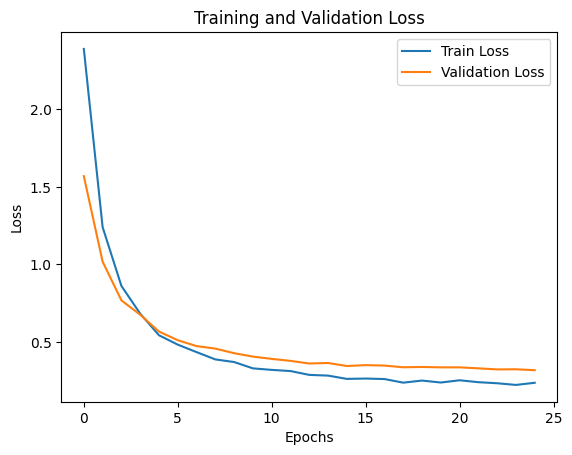

In [16]:
# Plot losses
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

Accuracy: 0.9238095238095239
Precision: 0.9259314837045929
Recall: 0.9316126994698424
F1-score: 0.9254145510658276


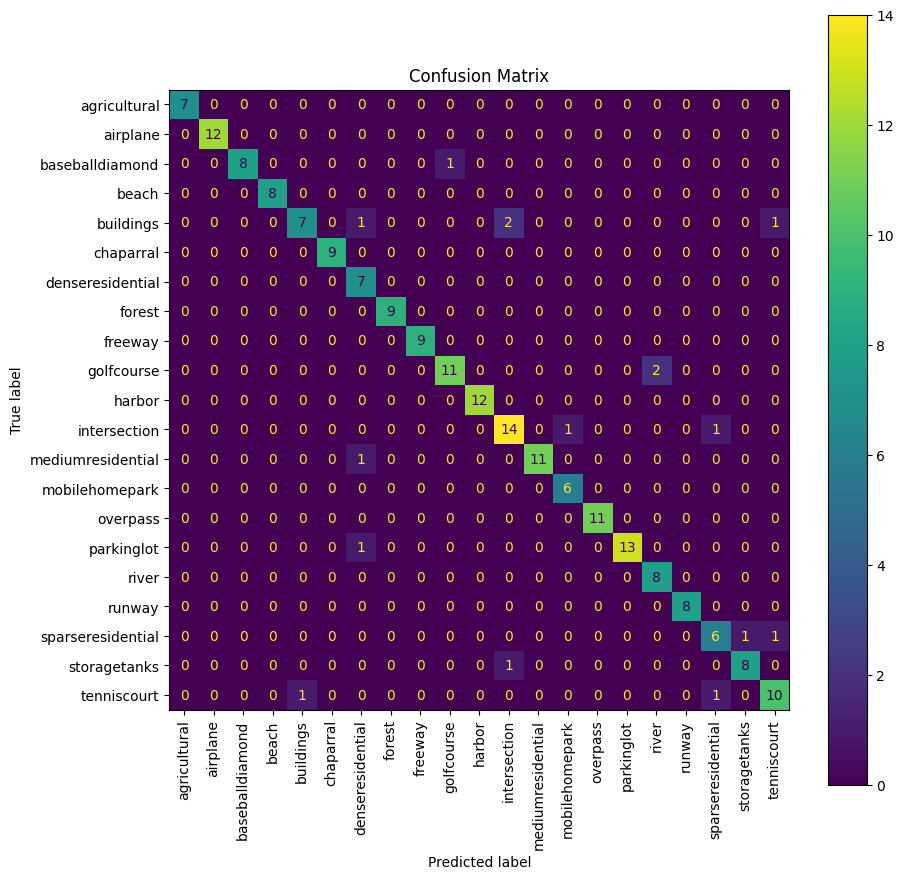

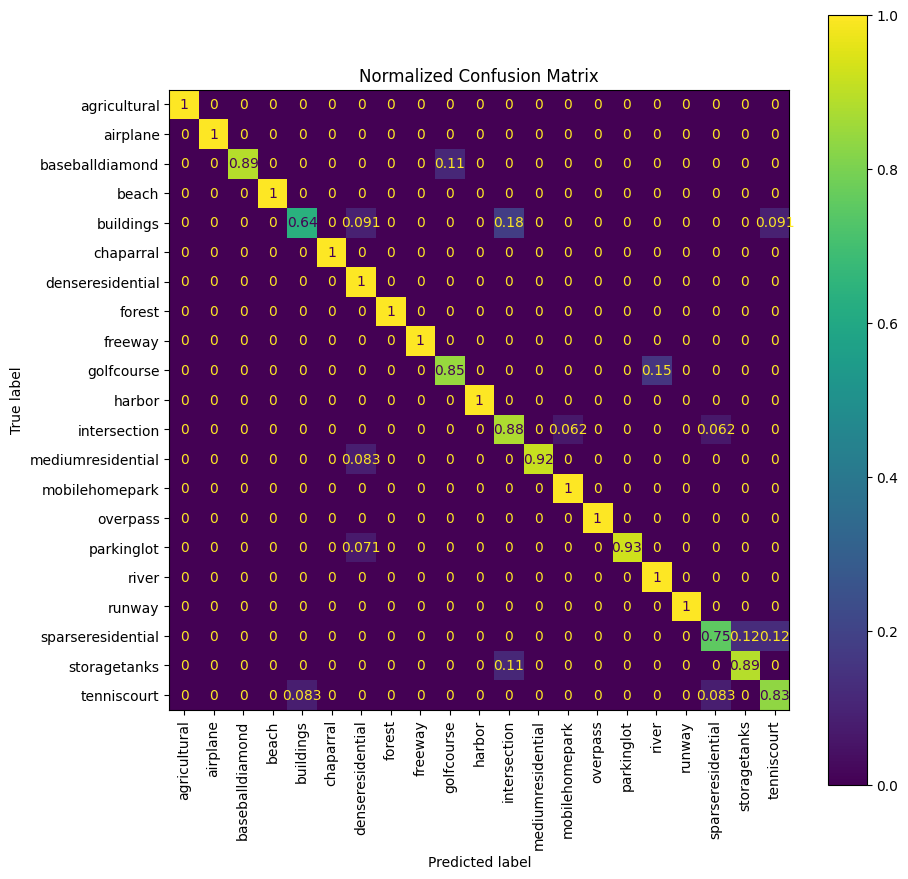

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Load best model
model.load_state_dict(torch.load("/content/best_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_to_idx.keys())
fig, ax = plt.subplots(figsize=(10, 10))  # Make it larger
disp.plot(ax=ax, xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

# Normalized Confusion Matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_to_idx.keys())
fig, ax = plt.subplots(figsize=(10, 10))
disp_norm.plot(ax=ax, xticks_rotation='vertical')
plt.title("Normalized Confusion Matrix")
plt.show()


## Comments on Task 2 :

Training only the classification head while freezing all other layers of the pretrained ResNet18 model didn’t lead to significant improvements over the baseline, like the SVM in Task 1. The network was trained for 25 epochs, and although the training and validation loss curves started to plateau around epoch 20–25, both losses stayed little high (~0.2 for train and ~0.3 for val). The final metrics were decent (Accuracy: 92%, Precision: 93%, Recall: 93%, F1-score: 93%), but they didn't outperform SVM. There was also more confusion between similar land-use classes. This shows that training only the classification head isn’t enough to adapt the model to the UCMerced dataset. The model couldn’t learn deeper or more useful features, which means full model fine-tuning or using a more capable architecture is likely needed to actually improve performance.


## Task 3 :  Modify and Unfreeze the Network

In [19]:
# ---
# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Send to device
model = model.to(device)



In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = ExponentialLR(optimizer, gamma=0.9)

best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(20):
    model.train()
    total_train_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    train_loss = total_train_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

    val_loss = total_val_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_finetuned_model.pth')

    scheduler.step()




Epoch 1, Train Loss: 0.1847, Val Loss: 0.1508
Epoch 2, Train Loss: 0.0282, Val Loss: 0.1087
Epoch 3, Train Loss: 0.0111, Val Loss: 0.1119
Epoch 4, Train Loss: 0.0056, Val Loss: 0.1085
Epoch 5, Train Loss: 0.0036, Val Loss: 0.1008
Epoch 6, Train Loss: 0.0032, Val Loss: 0.1018
Epoch 7, Train Loss: 0.0026, Val Loss: 0.1099
Epoch 8, Train Loss: 0.0019, Val Loss: 0.1058
Epoch 9, Train Loss: 0.0020, Val Loss: 0.1019
Epoch 10, Train Loss: 0.0015, Val Loss: 0.0994
Epoch 11, Train Loss: 0.0014, Val Loss: 0.1014
Epoch 12, Train Loss: 0.0013, Val Loss: 0.1060
Epoch 13, Train Loss: 0.0015, Val Loss: 0.1017
Epoch 14, Train Loss: 0.0012, Val Loss: 0.1051
Epoch 15, Train Loss: 0.0012, Val Loss: 0.1033
Epoch 16, Train Loss: 0.0010, Val Loss: 0.1038
Epoch 17, Train Loss: 0.0009, Val Loss: 0.1032
Epoch 18, Train Loss: 0.0010, Val Loss: 0.1040
Epoch 19, Train Loss: 0.0009, Val Loss: 0.1157
Epoch 20, Train Loss: 0.0008, Val Loss: 0.0937


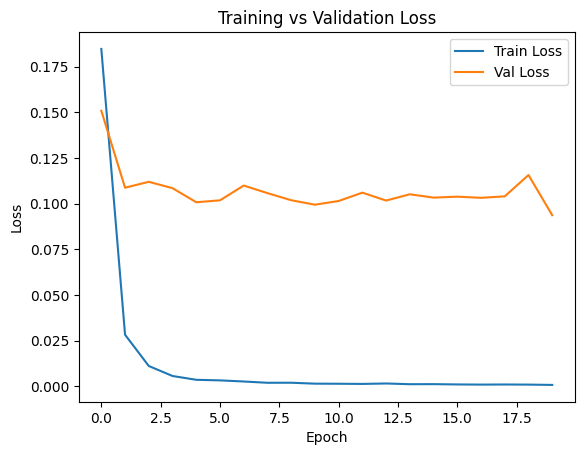

In [21]:

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


Accuracy: 0.9761904761904762
Precision: 0.9747448979591837
Recall: 0.9791065416065416
F1-Score: 0.9758351075570756


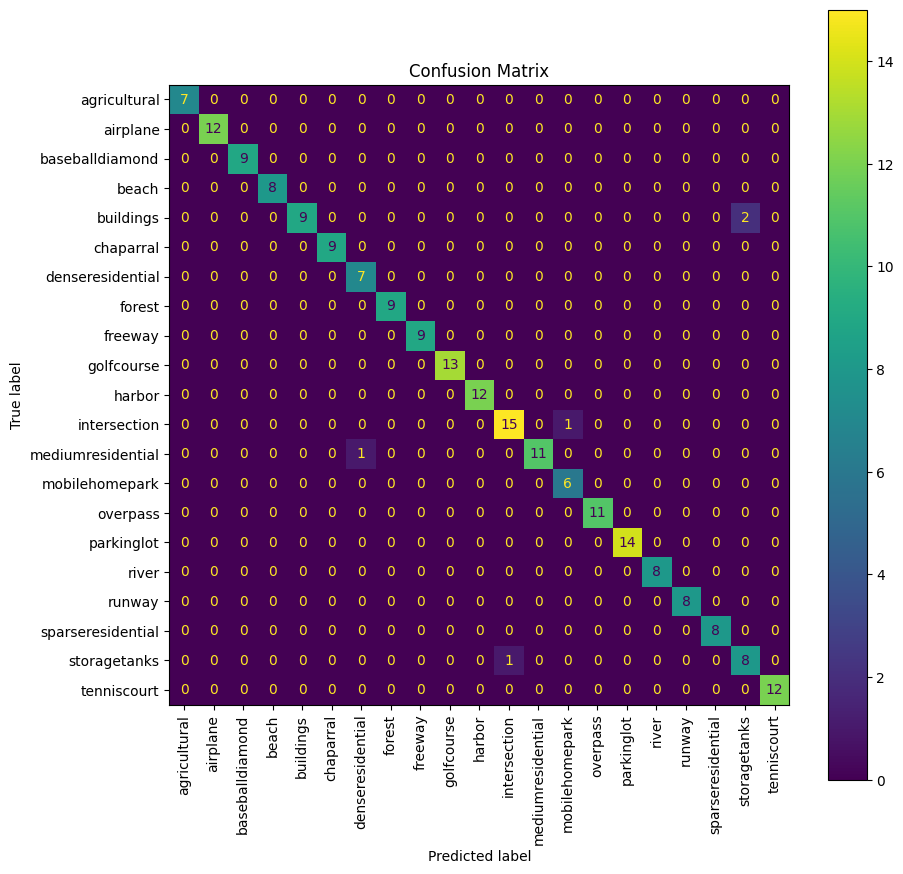

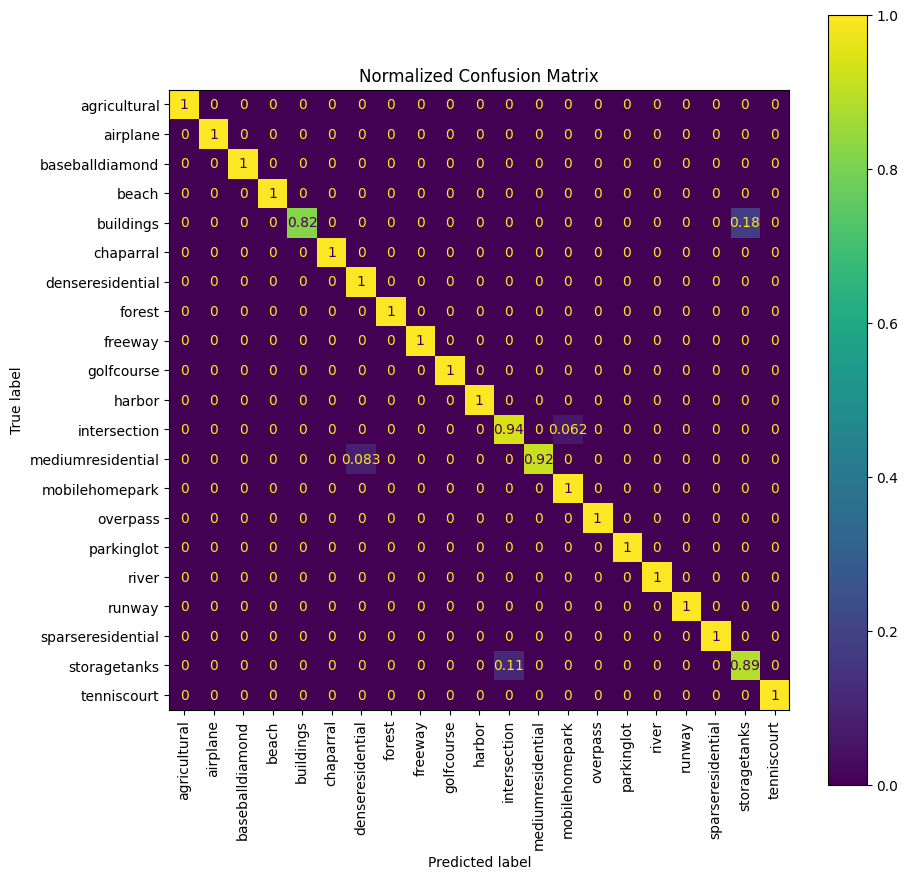

In [26]:
from sklearn.metrics import classification_report

# Load best model
model.load_state_dict(torch.load('best_finetuned_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Metrics
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds, average='macro'))
print("Recall:", recall_score(all_labels, all_preds, average='macro'))
print("F1-Score:", f1_score(all_labels, all_preds, average='macro'))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_to_idx.keys())
fig, ax = plt.subplots(figsize=(10, 10))  # Adjust the size (12x12 or as needed)
disp.plot(ax=ax, xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

# Normalized Confusion Matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_to_idx.keys())
fig, ax = plt.subplots(figsize=(10, 10))  # Adjust the size
disp_norm.plot(ax=ax, xticks_rotation='vertical')
plt.title("Normalized Confusion Matrix")
plt.show()



## Comments on Task 3 and Comparison of Task 1, 2 and 3 :

### Comments on Task 3 :

In the third case, where all layers were unfrozen and fine-tuned, the results showed a significant improvement. In just 20 epochs, the model achieved an exceptionally low training loss (0.0008) and a relatively low validation loss (0.0937). The performance metrics were very good outperfroming performance in both task 1 and 2 (Accuracy: 97.6%, Precision: 97.5%, Recall: 97.9%, F1-score: 97.6%), indicating that the model was not only able to fit the training data well but also generalize effectively to unseen data. The low training loss and higher validation loss suggested some degree of overfitting, but the high evaluation metrics imply that the model was still generalizing well, potentially due to the relatively small size of the validation dataset or the similarity between the training and validation sets. The model was though confused with some classes between buildings, storage tanks and intersections.

# Analysis on Comparison of Task 1, 2 and 3

Across all three tasks, we explored progressively deeper transfer learning strategies using a pretrained ResNet18 model on the UCMerced_LandUse dataset. The results clearly illustrate how the degree of fine-tuning impacts both learning dynamics and final performance.

**Task 1: Feature Extraction + SVM**

We used ResNet18 as a fixed feature extractor by removing its final classification layer and training a Support Vector Machine (SVM) on the extracted embeddings.

Performance on test set :

* Accuracy: 94%

* Precision: 95%

* Recall: 94%

* F1-score: 94%

This approach offered a strong baseline, demonstrating how well pretrained features from ImageNet can generalize to remote sensing imagery. For moderately sized datasets like UCMerced, traditional classifiers trained on high-quality features can already yield competitive results.

**Task 2: Head-Only Fine-Tuning**

Here, we froze all convolutional layers and fine-tuned only the final classification head.

Epochs: 25

Final Losses:

* Training Loss: ~0.23

* Validation Loss: ~0.30

Performance on test set :

* Accuracy: 92%

* Precision: 93%

* Recall: 93%

* F1-score: 93%

The training and validation losses plateaued after epoch 20, indicating limited learning. Although the model achieved decent test metrics, the performance didn’t surpass that of the SVM, and confusion increased among visually similar classes. This suggests that only updating the head was insufficient to adapt the model to the specific visual patterns of UCMerced.

**Task 3: Full Fine-Tuning**

In this approach, we unfroze all layers of the model and allowed the entire network to adapt to the dataset.


Final Losses:
* Training Loss: 0.0008

* Validation Loss: 0.0937

Performance on test set :

* Accuracy: 97.6%

* Precision: 97.5%

* Recall: 97.9%

* F1-score: 97.6%

This method clearly outperformed the previous two. While the gap between training and validation loss suggests some overfitting, the high evaluation metrics indicate strong generalization. The model benefited from being fully trainable, allowing it to learn deeper, task-specific representations.


 **Comparing all three cases**, the results raise an important question: if simple classifiers like SVM can achieve performance comparable to deeper networks using pretrained features, then for relatively simple or well-structured datasets like UCMerced, complex architectures or extensive fine-tuning may not be necessary. This highlights the practical value of lightweight approaches, especially when computational efficiency is a priority.